# Performance Analysis

In [69]:
#Load csv data from the app
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re


path_app_no_audio_folder = "data/app/no_audio/"
path_controller_no_audio_folder = "data/controller/no_audio/"
path_app_audio = "data/app/audio/"
path_controller_audio = "data/controller/audio/"

# The analyzed number of agents
no_audio_n_agents = [2 ** i for i in range(0, 12)]
no_audio_n_agents.append(2608)

audio_n_agents = [1, 2, 4, 8, 16, 32, 64, 128, 249]

# Extract date from filename and sort
def extract_datetime(format_search, format_date, filename):
    match = re.search(format_search, filename)
    if match:
        return pd.to_datetime(match.group(1), format=format_date)
    return pd.NaT

################ App NO AUDIO ################

# List all csv files in the folder
files_app_no_audio = [f for f in os.listdir(path_app_no_audio_folder) if f.endswith('.csv')]

# Use a regex pattern to extract the datetime from filenames
datetime_pattern_name_app = r"metric_(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})\.csv"
datetime_format_app = '%Y-%m-%d_%H-%M-%S'
files_sorted_app_no_audio = sorted(files_app_no_audio, key=lambda x: extract_datetime(datetime_pattern_name_app, datetime_format_app, x))

# Read csv files into a list of DataFrames
dfs_app_no_audio = [pd.read_csv(os.path.join(path_app_no_audio_folder, f)) for f in files_sorted_app_no_audio]

################ Controller NO AUDIO ################

files_controller_no_audio = [f for f in os.listdir(path_controller_no_audio_folder) if f.endswith('.csv')]
datetime_pattern_name_ctrl = r"delta_time_data_(\d{8}_\d{6})\.csv"
datetime_format_ctrl = '%Y%m%d_%H%M%S'
files_sorted_controller = sorted(files_controller_no_audio, key=lambda x: extract_datetime(datetime_pattern_name_ctrl, datetime_format_ctrl, x))
dfs_controller_no_audio = [pd.read_csv(os.path.join(path_controller_no_audio_folder, f), header=None, names=['dt']) for f in files_sorted_controller]

################ App AUDIO ################

files_app_audio = [f for f in os.listdir(path_app_audio) if f.endswith('.csv')]
files_sorted_app_audio = sorted(files_app_audio, key=lambda x: extract_datetime(datetime_pattern_name_app, datetime_format_app, x))
dfs_app_audio = [pd.read_csv(os.path.join(path_app_audio, f)) for f in files_sorted_app_audio]

################ Controller AUDIO ################

files_controller_audio = [f for f in os.listdir(path_controller_audio) if f.endswith('.csv')]
files_sorted_controller_audio = sorted(files_controller_audio, key=lambda x: extract_datetime(datetime_pattern_name_ctrl, datetime_format_ctrl, x))
dfs_controller_audio = [pd.read_csv(os.path.join(path_controller_audio, f), header=None, names=['dt']) for f in files_sorted_controller_audio]


In [95]:
# Display the statistics
def display_stats(stats_data):
    for i, stats in enumerate(stats_data):
        print(f"Stats for no_audio_n_agents={no_audio_n_agents[i]}:")
        print(stats)
        print("-" * 40)

def process_frametime_stats_app(dfs_app):
    # Apply descriptive statistics to the 'frametime' column for each DataFrame in dfs_no_audio
    frametime_stats_app= [df['frametime'].describe() for df in dfs_app]

    # Calculate the difference between the last and first value in column 't' for each DataFrame
    t_diffs = [df['t'].iloc[-1] - df['t'].iloc[0] for df in dfs_app]

    # Add the difference to the stats as a new entry
    for stats, t_diff in zip(frametime_stats_app, t_diffs):
        stats['t_diff'] = t_diff

    for stats in frametime_stats_app:
        stats['mean_ms'] = stats['mean'] * 1000
        stats['std_ms'] = stats['std'] * 1000

    # Display the statistics for the no audio case
    #display_stats(frametime_stats_app)
    return frametime_stats_app

def process_frametime_stats_ctrl(dfs_ctrl):
    # Apply descriptive statistics to the 'frametime' column for each DataFrame in dfs_no_audio
    dt_stats_controller = [df['dt'].describe() for df in dfs_ctrl]

    for stats in dt_stats_controller:
        stats['mean_ms'] = stats['mean'] * 1000
        stats['std_ms'] = stats['std'] * 1000

    # Display the statistics
    #display_stats(frametime_stats_controller)
    return dt_stats_controller

In [97]:
frametime_stats_app_no_audio = process_frametime_stats_app(dfs_app_no_audio)
frametime_stats_controller_no_audio = process_frametime_stats_ctrl(dfs_controller_no_audio)

frametime_stats_app_audio = process_frametime_stats_app(dfs_app_audio)
frametime_stats_controller_audio = process_frametime_stats_ctrl(dfs_controller_audio)


In [167]:
def plot_performance(frametime_app_data_no_audio, 
                     frametime_ctrl_data_no_audio,
                    frametime_app_data_audio,
                    frametime_ctrl_data_audio, x_limit=None, y_limit=None, steps = 10, xscale='linear', figsize=(10, 6), show_legend=True, file_name='performance_plot.pdf'):
    # Prepare data for plotting
    mean_ms_app_no_audio = [stats['mean_ms'] for stats in frametime_app_data_no_audio]
    std_ms_app_no_audio = [stats['std_ms'] for stats in frametime_app_data_no_audio]

    mean_ms_ctrl_no_audio = [stats['mean_ms'] for stats in frametime_ctrl_data_no_audio]
    std_ms_ctrl_no_audio = [stats['std_ms'] for stats in frametime_ctrl_data_no_audio]

    mean_ms_app_audio = [stats['mean_ms'] for stats in frametime_app_data_audio]
    std_ms_app_audio = [stats['std_ms'] for stats in frametime_app_data_audio]

    mean_ms_ctrl_audio = [stats['mean_ms'] for stats in frametime_ctrl_data_audio]
    std_ms_ctrl_audio = [stats['std_ms'] for stats in frametime_ctrl_data_audio]

    plt.figure(figsize=figsize)
    def plot_individual_data(n_agents, mean_data, std_data, system_name, condition_name, color, line_style ='-'):
        plt.plot(n_agents, mean_data, label=system_name + ' Frametime Mean (ms) - ' + condition_name, color=color, linestyle=line_style)
        plt.fill_between(n_agents,
                        np.array(mean_data) - np.array(std_data),
                        np.array(mean_data) + np.array(std_data),
                        color=color, alpha=0.2, label=system_name + ' Frametime Std Dev (ms) - ' + condition_name)
        plt.scatter(n_agents, mean_data, color=color, marker='o', s=10)

    # App frametime no audio
    plot_individual_data(no_audio_n_agents, mean_ms_app_no_audio, std_ms_app_no_audio, 'HS-ims','No Audio', 'blue')

    # Controller dt no audio
    plot_individual_data(no_audio_n_agents, mean_ms_ctrl_no_audio, std_ms_ctrl_no_audio, 'Controller', 'No Audio', 'orange')

    # App frametime audio
    plot_individual_data(audio_n_agents, mean_ms_app_audio, std_ms_app_audio, 'HS-ims', 'Audio', 'green', '--')

    # Controller dt audio
    plot_individual_data(audio_n_agents, mean_ms_ctrl_audio, std_ms_ctrl_audio, 'Controller', 'Audio', 'red', '--')

    plt.xscale(xscale)
    plt.xlabel('Number of Agents')
    plt.ylabel('Milliseconds (ms)')
    plt.title('System Performance per Number of Agents')
    if show_legend:
        plt.legend(loc='upper left')
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    if y_limit is not None:
        plt.yticks(np.arange(0, y_limit + steps, steps))
        plt.ylim(0, y_limit)
    else:
        plt.yticks(np.arange(0, max(max(mean_ms_app_no_audio) + max(std_ms_app_no_audio), max(mean_ms_ctrl_no_audio) + max(std_ms_ctrl_no_audio)) + steps, steps))
    if x_limit is not None:
        plt.xlim(left=0, right=x_limit)
    else:
        plt.xlim(left=0)
    plt.tight_layout()

     #Save ax2 in pdf format
    save_file = True
    if save_file:
        plt.tight_layout()
        plt.savefig('data/' + file_name, format='pdf', bbox_inches='tight')

    plt.show()

C:\Users\pitte\AppData\Local\Temp\ipykernel_6244\1099534529.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


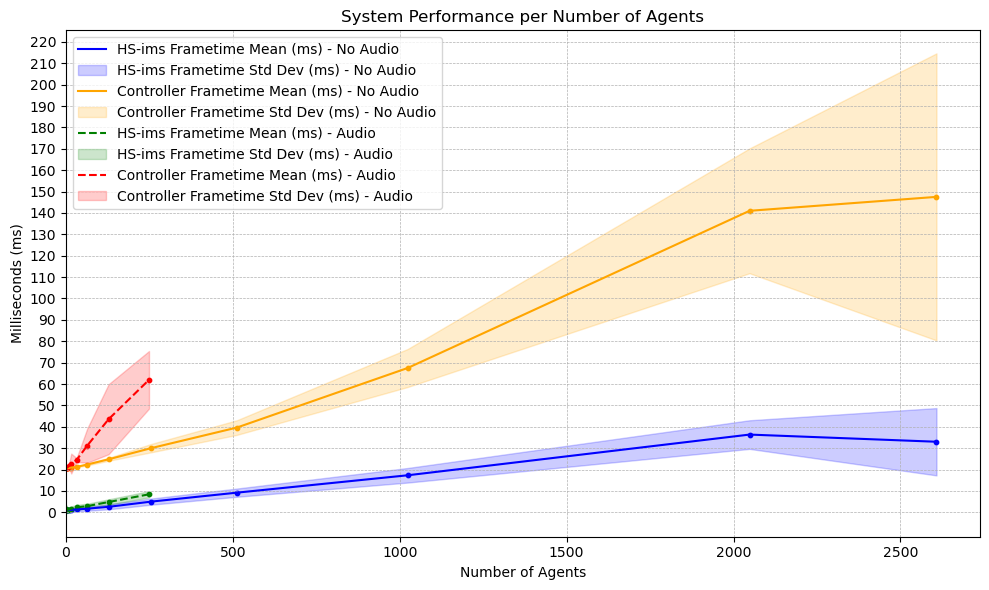

In [168]:
plot_performance(frametime_stats_app_no_audio, 
                 frametime_stats_controller_no_audio,
                 frametime_stats_app_audio,
                 frametime_stats_controller_audio, figsize=(10, 6), show_legend=True,
                 file_name='performance_2000.pdf')

C:\Users\pitte\AppData\Local\Temp\ipykernel_6244\1099534529.py:60: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


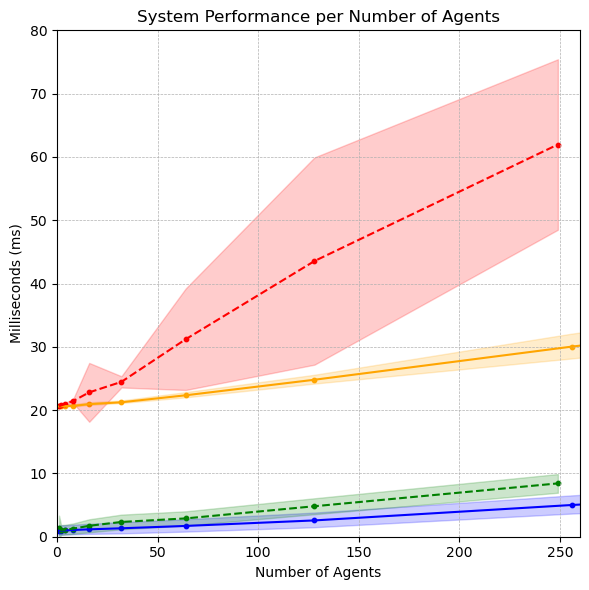

In [169]:
plot_performance(frametime_stats_app_no_audio, 
                 frametime_stats_controller_no_audio,
                 frametime_stats_app_audio,
                 frametime_stats_controller_audio, 260, 80, steps=10, xscale='linear', figsize=(6, 6), show_legend=False,
                 file_name='performance_280.pdf')